## Data Exploration

In [221]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/srikan/.cache/kagglehub/datasets/suraj520/customer-support-ticket-dataset/versions/1


In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [223]:
df = pd.read_csv("/home/srikan/Invulnerable/realtime-agent-framework/data/customer_support_tickets.csv")

In [224]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [226]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [227]:
df.tail()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,There seems to be a hardware problem with my {...,Open,NaN,High,Phone,NaN,NaN,NaN


In [228]:
# keeping a copy of dataframe
data = df

### Columns to drop since there's no use for this columns 

In [229]:
drop_columns = [
    "Ticket ID",
    "Customer Name",
    "Customer Email",
    "Customer Gender"
]
df.drop(columns=drop_columns, inplace=True)


In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer Age                  8469 non-null   int64  
 1   Product Purchased             8469 non-null   object 
 2   Date of Purchase              8469 non-null   object 
 3   Ticket Type                   8469 non-null   object 
 4   Ticket Subject                8469 non-null   object 
 5   Ticket Description            8469 non-null   object 
 6   Ticket Status                 8469 non-null   object 
 7   Resolution                    2769 non-null   object 
 8   Ticket Priority               8469 non-null   object 
 9   Ticket Channel                8469 non-null   object 
 10  First Response Time           5650 non-null   object 
 11  Time to Resolution            2769 non-null   object 
 12  Customer Satisfaction Rating  2769 non-null   float64
dtypes: 

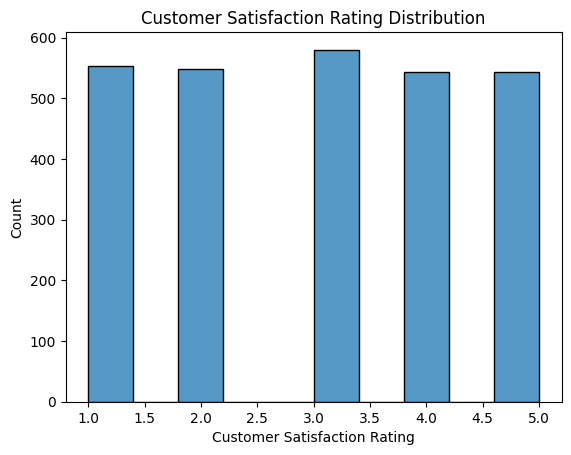

In [231]:
sns.histplot(df['Customer Satisfaction Rating'].dropna(),bins=10)
plt.title("Customer Satisfaction Rating Distribution")
plt.show()

In [232]:
df.drop_duplicates(inplace=True)
df.shape

(8469, 13)

In [233]:
print(df['Customer Age'].min())
print(df['Customer Age'].max())

18
70


In [234]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Customer Age: 53
Product Purchased: 42
Date of Purchase: 730
Ticket Type: 5
Ticket Subject: 16
Ticket Description: 8077
Ticket Status: 3
Resolution: 2769
Ticket Priority: 4
Ticket Channel: 4
First Response Time: 5470
Time to Resolution: 2728
Customer Satisfaction Rating: 5


In [235]:
labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["Age_Group"] = pd.cut(
    df["Customer Age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=labels
)


In [236]:
df.drop(columns=["Customer Age"], inplace=True)


In [237]:
df.head()

,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Age_Group
0,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,26-35
1,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,36-45
2,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,46-55
3,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,26-35
4,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,66+


In [238]:
# since the ticket was not resolved
df["Resolution"] = df["Resolution"].fillna("Not Resolved")


In [239]:
df["First Response Time"] = pd.to_datetime(
    df["First Response Time"], errors="coerce"
)

df["Time to Resolution"] = pd.to_datetime(
    df["Time to Resolution"], errors="coerce"
)


In [240]:
# Since we don’t have ticket creation time, we approximate using first response time
df["Resolution_Time_Hours"] = (
    df["Time to Resolution"] - df["First Response Time"]
).dt.total_seconds() / 3600


In [241]:
df["First_Response_Hour"] = df["First Response Time"].dt.hour


In [242]:
df["Resolution_Time_Hours"] = df["Resolution_Time_Hours"].fillna(
    df["Resolution_Time_Hours"].median()
)


In [243]:
df.drop(
    columns=["First Response Time", "Time to Resolution"],
    inplace=True
)


In [244]:
df.loc[df["Resolution_Time_Hours"] < 0, "Resolution_Time_Hours"] = \
    df["Resolution_Time_Hours"].median()


In [245]:
df.isnull().sum()

Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                         0
Ticket Priority                    0
Ticket Channel                     0
Customer Satisfaction Rating    5700
Age_Group                          0
Resolution_Time_Hours              0
First_Response_Hour             2819
dtype: int64

In [246]:
#Customer Satisfaction Rating

#Use median imputation (best for ordinal numeric data).
csat_median = df["Customer Satisfaction Rating"].median()
df["Customer Satisfaction Rating"] = df[
    "Customer Satisfaction Rating"
].fillna(csat_median)


In [247]:
# -1 indicates no response

df["First_Response_Hour"] = df["First_Response_Hour"].fillna(-1)


In [248]:
df.isnull().sum()

Product Purchased               0
Date of Purchase                0
Ticket Type                     0
Ticket Subject                  0
Ticket Description              0
Ticket Status                   0
Resolution                      0
Ticket Priority                 0
Ticket Channel                  0
Customer Satisfaction Rating    0
Age_Group                       0
Resolution_Time_Hours           0
First_Response_Hour             0
dtype: int64

In [249]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Product Purchased: 42
Date of Purchase: 730
Ticket Type: 5
Ticket Subject: 16
Ticket Description: 8077
Ticket Status: 3
Resolution: 2770
Ticket Priority: 4
Ticket Channel: 4
Customer Satisfaction Rating: 5
Age_Group: 6
Resolution_Time_Hours: 780
First_Response_Hour: 25


# Encoding (object to numerical)

In [250]:
one_hot_cols = [
    "Ticket Type",
    "Ticket Status",
    "Ticket Channel",
    "Age_Group"
]

df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)


In [251]:
priority_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Critical": 3
}

df["Ticket_Priority_Encoded"] = df["Ticket Priority"].map(priority_map)



In [252]:
from sklearn.preprocessing import LabelEncoder

le_product = LabelEncoder()
df["Product_Encoded"] = le_product.fit_transform(df["Product Purchased"])


In [253]:
df["Purchase_Year"] = pd.to_datetime(df["Date of Purchase"]).dt.year
df["Purchase_Month"] = pd.to_datetime(df["Date of Purchase"]).dt.month


In [254]:
df.drop(columns=['Date of Purchase',"Ticket Priority"],axis=1,inplace=True)

In [255]:
df.head()

,Product Purchased,Ticket Subject,Ticket Description,Resolution,Customer Satisfaction Rating,Resolution_Time_Hours,First_Response_Hour,Ticket Type_Cancellation request,Ticket Type_Product inquiry,Ticket Type_Refund request,...,Ticket Channel_Social media,Age_Group_26-35,Age_Group_36-45,Age_Group_46-55,Age_Group_56-65,Age_Group_66+,Ticket_Priority_Encoded,Product_Encoded,Purchase_Year,Purchase_Month
0,GoPro Hero,Product setup,I'm having an issue with the {product_purchase...,Not Resolved,3.0,0.166667,12.0,False,False,False,...,True,True,False,False,False,False,3,16,2021,3
1,LG Smart TV,Peripheral compatibility,I'm having an issue with the {product_purchase...,Not Resolved,3.0,0.166667,16.0,False,False,False,...,False,False,True,False,False,False,3,21,2021,5
2,Dell XPS,Network problem,I'm facing a problem with my {product_purchase...,Case maybe show recently my computer follow.,3.0,6.850000,11.0,False,False,False,...,True,False,False,True,False,False,0,10,2020,7
3,Microsoft Office,Account access,I'm having an issue with the {product_purchase...,Try capital clearly never color toward story.,3.0,0.166667,7.0,False,False,False,...,True,True,False,False,False,False,0,25,2020,11
4,Autodesk AutoCAD,Data loss,I'm having an issue with the {product_purchase...,West decision evidence bit.,1.0,19.683333,0.0,False,False,False,...,False,False,False,False,False,True,0,5,2020,2


In [256]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\{.*?\}", "", text)   # remove placeholders
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [257]:
nlp_cols = [
    "Product Purchased",
    "Ticket Subject",
    "Ticket Description",
    "Resolution"
]

for col in nlp_cols:
    df[col] = df[col].apply(clean_text)


In [258]:
df["combined_text"] = (
    df["Product Purchased"] + " " +
    df["Ticket Subject"] + " " +
    df["Ticket Description"] + " " +
    df["Resolution"]
)


In [259]:
df_structured = df.drop(
    columns=[
        "Product Purchased",
        "Ticket Subject",
        "Ticket Description",
        "Resolution",
        "combined_text",
        "Customer Satisfaction Rating"  # ✅ IMPORTANT
    ]
)


In [260]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_text = tfidf.fit_transform(df["combined_text"])


In [261]:
df_structured = df_structured.astype(float)

In [262]:
from scipy.sparse import csr_matrix

X_structured = csr_matrix(df_structured.values)


In [263]:
from scipy.sparse import csr_matrix

X_structured = csr_matrix(df_structured.values)


In [264]:
from scipy.sparse import hstack

X_final = hstack([X_text, X_structured])


In [265]:
X_final.shape

(8469, 5020)

# Train Test Split

In [266]:
y = df["Customer Satisfaction Rating"]


In [267]:
from sklearn.model_selection import train_test_split as tts

In [268]:
X_train,X_test,y_train,y_test = tts(x,y,test_size=0.25,random_state=42)

In [269]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42
)


In [271]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [272]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 1.2160467542827007
RMSE: 1.6583628492282885
